In [1]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

In [2]:
df = pd.read_sql(
    "SELECT * FROM customers_processed",
    engine
)

print(df.shape)

(7043, 43)


In [3]:
# Feature 1
df["charge_per_tenure"] = (
    df["total_charges"] /
    (df["tenure"] + 1)
)

print("✓ charge_per_tenure created")

✓ charge_per_tenure created


In [4]:
df.to_sql(
    "customers_processed",
    engine,
    if_exists="replace",
    index=False,
    method="multi"
)

print("Feature engineering completed.")

Feature engineering completed.


In [5]:
print(df[["customer_id", "tenure", "total_charges", "charge_per_tenure"]].head(10))

  customer_id  tenure  total_charges  charge_per_tenure
0  7590-VHVEG       1          29.85          14.925000
1  5575-GNVDE      34        1889.50          53.985714
2  3668-QPYBK       2         108.15          36.050000
3  7795-CFOCW      45        1840.75          40.016304
4  9237-HQITU       2         151.65          50.550000
5  9305-CDSKC       8         820.50          91.166667
6  1452-KIOVK      22        1949.40          84.756522
7  6713-OKOMC      10         301.90          27.445455
8  7892-POOKP      28        3046.05         105.036207
9  6388-TABGU      62        3487.95          55.364286


In [6]:
print(df["charge_per_tenure"].describe())

count    7043.000000
mean       61.173413
std        61.019723
min         9.183333
25%        26.274411
50%        61.150000
75%        84.940047
max      1397.475000
Name: charge_per_tenure, dtype: float64


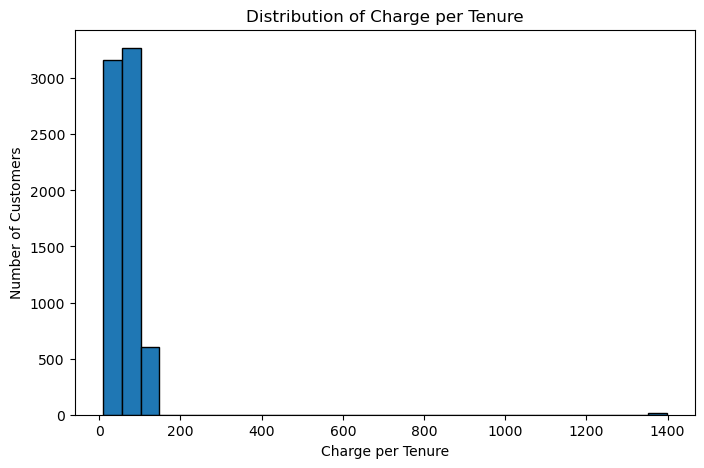

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["charge_per_tenure"], bins=30, edgecolor="black")

plt.title("Distribution of Charge per Tenure")
plt.xlabel("Charge per Tenure")
plt.ylabel("Number of Customers")

plt.show()

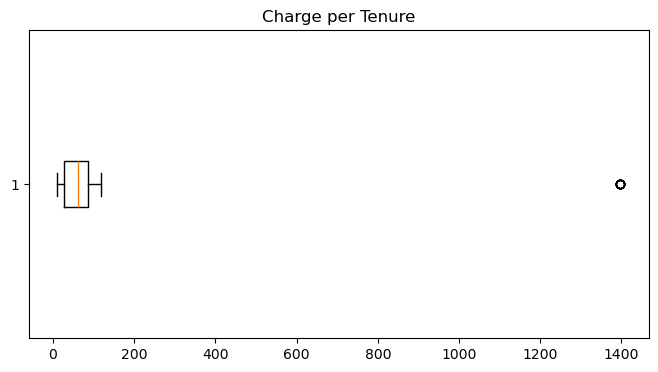

In [8]:
plt.figure(figsize=(8,4))

plt.boxplot(df["charge_per_tenure"], vert=False)

plt.title("Charge per Tenure")

plt.show()

<Figure size 800x500 with 0 Axes>

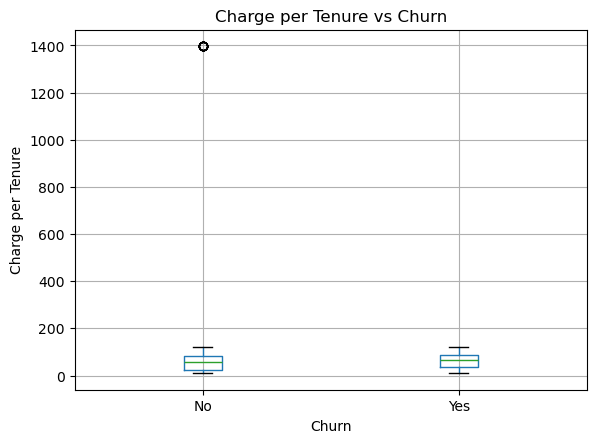

In [9]:
plt.figure(figsize=(8,5))

df.boxplot(column="charge_per_tenure", by="churn")

plt.title("Charge per Tenure vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Charge per Tenure")

plt.show()

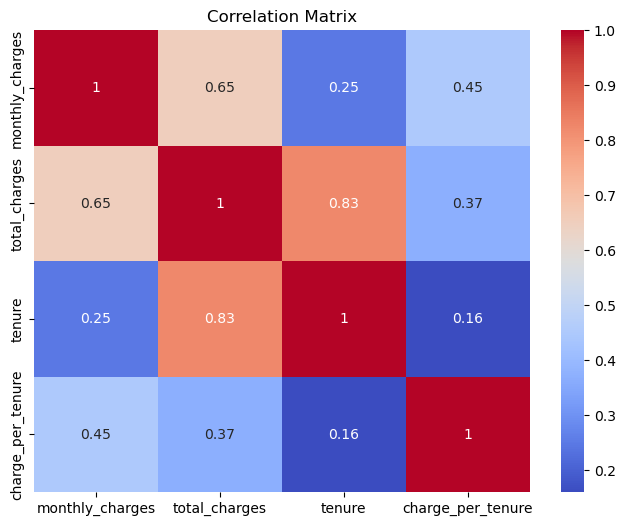

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    df[["monthly_charges","total_charges","tenure","charge_per_tenure"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# =====================================================
# STEP 1 — CONNECT TO POSTGRESQL
# =====================================================

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

# =====================================================
# STEP 2 — LOAD PREPROCESSED DATA
# =====================================================

print("=" * 60)
print("FEATURE ENGINEERING — FEATURE 1")
print("=" * 60)

df = pd.read_sql(
    "SELECT * FROM customers_processed",
    engine
)

print(f"Dataset Loaded Successfully")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")


# =====================================================
# STEP 3 — CREATE FEATURE
# =====================================================

if "charge_per_tenure" in df.columns:
    print("\nExisting 'charge_per_tenure' found. Recalculating feature...")
else:
    print("\nCreating Feature: charge_per_tenure")

# Always calculate (create or overwrite)
df["charge_per_tenure"] = (
    df["total_charges"] /
    (df["tenure"] + 1)
)

print("✓ Feature created successfully.")

# =====================================================
# STEP 4 — FEATURE VALIDATION
# =====================================================

print("\nFeature Statistics")
print("-" * 40)

print(df["charge_per_tenure"].describe().round(2))

print("\nMissing Values :", df["charge_per_tenure"].isnull().sum())
print("Duplicate Rows :", df.duplicated().sum())

# =====================================================
# STEP 5 — SAVE UPDATED DATASET
# =====================================================

df.to_sql(
    "customers_processed",
    engine,
    if_exists="replace",
    index=False,
    method="multi"
)

print("\n✓ Updated dataset saved successfully.")

# Verify saved data
verify_df = pd.read_sql(
    "SELECT charge_per_tenure FROM customers_processed LIMIT 5",
    engine
)

print("\nVerification (First 5 Values)")
print(verify_df)

# =====================================================
# FINAL FINDINGS
# =====================================================

print("\n" + "=" * 60)
print("Feature Engineering Pipeline Completed Successfully")
print("FEATURE ENGINEERING REPORT")
print("=" * 60)

print(f"Feature Name               : charge_per_tenure")
print(f"Formula                    : total_charges / (tenure + 1)")
print(f"Total Customers            : {len(df)}")
print(f"Average Value              : {df['charge_per_tenure'].mean():.2f}")
print(f"Median Value               : {df['charge_per_tenure'].median():.2f}")
print(f"Minimum Value              : {df['charge_per_tenure'].min():.2f}")
print(f"Maximum Value              : {df['charge_per_tenure'].max():.2f}")

high_spenders = (
    df["charge_per_tenure"] >
    df["charge_per_tenure"].quantile(0.75)
).sum()

print(f"Top 25% High Charge-per-Tenure Customers : {high_spenders}")

print("\nBusiness Findings:")
print("-" * 40)
print("• Successfully engineered the 'charge_per_tenure' feature by combining customer tenure and total spending.")
print("• The feature captures customer spending intensity throughout their relationship with the company.")
print("• Customers with higher charge_per_tenure have contributed more revenue relative to their tenure and can be analyzed as potential high-value customers.")
print("• Extremely high values may occur for customers with short tenure and high initial charges, making them important candidates for further churn analysis.")
print("• This engineered feature provides additional business information beyond using total_charges or tenure independently.")
print("• The feature will be included in the machine learning model to evaluate its contribution to customer churn prediction.")

print("\n✓ Feature Engineering completed successfully.")


FEATURE 1 — CHARGE PER TENURE
✓ Feature 'charge_per_tenure' created successfully.

Feature Summary
----------------------------------------
count    7043.00
mean       61.17
std        61.02
min         9.18
25%        26.27
50%        61.15
75%        84.94
max      1397.48
Name: charge_per_tenure, dtype: float64

✓ Updated dataset saved to PostgreSQL.

FEATURE ENGINEERING FINDINGS
Feature Name               : charge_per_tenure
Formula                    : total_charges / (tenure + 1)
Total Customers            : 7043
Average Value              : 61.17
Median Value               : 61.15
Minimum Value              : 9.18
Maximum Value              : 1397.47
Top 25% High Charge-per-Tenure Customers : 1761

Business Findings:
----------------------------------------
• Successfully engineered the 'charge_per_tenure' feature by combining customer tenure and total spending.
• The feature captures customer spending intensity throughout their relationship with the company.
• Customers with h